BOOSTING TECHNIQUE | DA-AG-015

Question 1: What is Boosting in Machine Learning? Explain how it improves weak
learners.


---
Answer: Boosting is an ensemble learning technique that turns weak learners into a strong predictive model by training them sequentially, each one correcting the errors of the previous. It improves accuracy by focusing more on hard-to-classify data points and combining all learners into a weighted final model.

Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?


---
Answer: AdaBoost and Gradient Boosting both improve weak learners, but they differ in how they train models.AdaBoost adjusts sample weights to emphasize misclassified points, while Gradient Boosting fits new learners to the residual errors using gradient descent.


Question 3: How does regularization help in XGBoost?


---
Answer: Regularization in XGBoost helps prevent overfitting by penalizing overly complex models, ensuring better generalization to unseen data. It uses techniques like L1 (Lasso), L2 (Ridge), minimum child weight, gamma, and early stopping to control complexity and reduce noise fitting.

Question 4: Why is CatBoost considered efficient for handling categorical data?


---
Answer:CatBoost is considered highly efficient for handling categorical data because it uses advanced encoding techniques that avoid overfitting and reduce preprocessing effort. Unlike other boosting algorithms, CatBoost can directly process categorical features without requiring manual one-hot encoding or label encoding.


Question 5: What are some real-world applications where boosting techniques are
preferred over bagging methods?


---
Answer: Boosting techniques are preferred over bagging methods in real-world applications where reducing bias and improving accuracy on complex datasets is more important than just reducing variance. They are widely used in domains like fraud detection, spam filtering, medical diagnosis, and financial risk modeling.


In [1]:
# Question 6: Write a Python program to:
# ● Train an AdaBoost Classifier on the Breast Cancer dataset
# ● Print the model accuracy

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=2)

clf = AdaBoostClassifier()
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(f'Model Accuracy {accuracy_score(y_test,y_pred)}')

Model Accuracy 0.958041958041958


In [2]:
# Question 7: Write a Python program to:
# ● Train a Gradient Boosting Regressor on the California Housing dataset
# ● Evaluate performance using R-squared score

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

data = fetch_california_housing()
X = data.data
y = data.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

reg = GradientBoostingRegressor()
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print(f'R-Squared Score {r2_score(y_test,y_pred)}')

R-Squared Score 0.7846424934845743


In [3]:
# Question 8: Write a Python program to:
# ● Train an XGBoost Classifier on the Breast Cancer dataset
# ● Tune the learning rate using GridSearchCV
# ● Print the best parameters and accuracy

import xgboost as xgb
from sklearn.model_selection import GridSearchCV

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_clf = xgb.XGBClassifier(eval_metric='logloss',random_state=42)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
    }

grid_search = GridSearchCV(estimator=xgb_clf,param_grid=param_grid,scoring='accuracy',cv=5)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

y_pred = grid_search.best_estimator_.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Best Parameters: {'learning_rate': 0.2}
Test Accuracy: 0.956140350877193


Test Accuracy: 0.9649122807017544


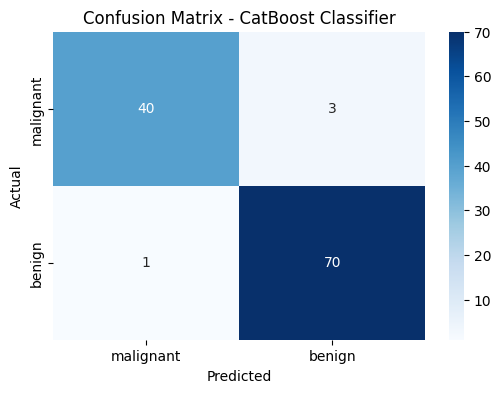

In [4]:
# Question 9: Write a Python program to:
# ● Train a CatBoost Classifier
# ● Plot the confusion matrix using seaborn

from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(iterations=200,learning_rate=0.1,depth=6,verbose=0,random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=data.target_names,yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CatBoost Classifier")
plt.show()

Question 10: You're working for a FinTech company trying to predict loan default using customer demographics and transaction behavior. The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.Describe your step-by-step data science pipeline using boosting techniques:
- Data preprocessing & handling missing/categorical values
- Choice between AdaBoost, XGBoost, or CatBoost
-  Hyperparameter tuning strategy
-  Evaluation metrics you'd choose and why
-  How the business would benefit from your model
---
Answer:
The pipeline, start with Data preprocessing, imputing missing values (median for numeric, mode or “missing” category for categorical), handling imbalance with class weights or SMOTE, and encoding categorical features (CatBoost can handle them directly). Given the dataset’s mix of numeric and categorical features plus missing values, CatBoost is the most efficient choice. Hyperparameter tuning would involve GridSearchCV or RandomizedSearchCV, focusing on parameters like learning rate, depth, iterations, and class weights, with early stopping to prevent overfitting. For evaluation, metrics like ROC-AUC, Precision-Recall AUC, and F1-score are preferred over accuracy since the data is imbalanced, with special attention to minimizing false negatives (missed defaults). The business benefits include better risk management, reduced loan losses, smarter customer segmentation, automated underwriting, and stronger compliance, ultimately improving profitability and customer trust.
